In [5]:
import pandas as pd

csv_path = "/home/Shelby/blackbird_calls/Experiments/Detection_of_calls/Datasets/All_call_classes/Split_data_controlled/OpenSoundScape/birds_embeddings_birdnet_padded_3s.csv"
df = pd.read_csv(csv_path)
df

,calltype,file,start_time,end_time,0,1,2,3,4,5,...,1014,1015,1016,1017,1018,1019,1020,1021,1022,1023
0,D,/home/Shelby/blackbird_calls/Experiments/Detec...,0.0,3.0,0.067894,0.344097,0.135184,0.049056,0.659216,1.029421,...,0.000000,0.000000,0.283043,0.353124,0.850524,0.342322,0.000000,1.061636,0.762078,0.485685
1,F,/home/Shelby/blackbird_calls/Experiments/Detec...,0.0,3.0,0.027922,0.142469,0.005187,0.067271,0.845247,0.754935,...,0.000000,0.000000,0.565755,0.272597,0.313492,0.231603,0.067483,1.466044,1.240883,0.785682
2,F,/home/Shelby/blackbird_calls/Experiments/Detec...,0.0,3.0,0.063137,0.392312,0.081558,0.013896,0.519530,0.799999,...,0.007743,0.083630,0.350261,0.338610,0.525507,0.445224,0.000000,0.847136,0.351975,0.716970
3,Cheer,/home/Shelby/blackbird_calls/Experiments/Detec...,0.0,3.0,0.247558,0.025925,0.128917,0.579505,0.000000,0.203117,...,0.250644,0.000000,0.057046,0.103796,1.025722,0.991909,0.000000,0.515161,0.025441,1.636110
4,Check,/home/Shelby/blackbird_calls/Experiments/Detec...,0.0,3.0,0.023261,0.383073,0.003367,0.000000,0.256864,0.177266,...,0.000000,0.000597,1.142428,0.817335,0.477512,0.280269,0.000000,2.258079,0.730854,0.299776
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6042,Check,/home/Shelby/blackbird_calls/Experiments/Detec...,0.0,3.0,0.037597,0.342866,0.100045,0.000000,0.663393,0.497607,...,0.000000,0.000000,0.458764,0.260673,0.779880,0.335959,0.000000,1.328580,0.665761,0.626578
6043,K,/home/Shelby/blackbird_calls/Experiments/Detec...,0.0,3.0,0.000000,0.642851,0.037707,0.313084,0.296117,0.119701,...,0.000000,0.048159,0.047531,0.064807,0.008464,0.931550,0.000000,0.954245,0.235279,1.080495
6044,Check,/home/Shelby/blackbird_calls/Experiments/Detec...,0.0,3.0,0.043629,1.309853,0.000000,0.000000,0.528510,0.212673,...,0.000000,0.000000,1.012889,0.316343,1.167196,0.529842,0.000000,1.904490,0.844413,0.330008
6045,Chits,/home/Shelby/blackbird_calls/Experiments/Detec...,0.0,3.0,0.201546,0.567811,0.340353,0.064018,0.000000,0.188472,...,0.484483,0.000000,0.049928,0.000000,0.818705,0.544184,0.000000,0.432003,0.000000,0.481858


Test different perplexities

Testing different perplexity values...
This will take several minutes...

Testing perplexity=5...
[t-SNE] Computing 16 nearest neighbors...
[t-SNE] Indexed 6047 samples in 0.017s...
[t-SNE] Computed neighbors for 6047 samples in 0.338s...
[t-SNE] Computed conditional probabilities for sample 1000 / 6047
[t-SNE] Computed conditional probabilities for sample 2000 / 6047
[t-SNE] Computed conditional probabilities for sample 3000 / 6047
[t-SNE] Computed conditional probabilities for sample 4000 / 6047
[t-SNE] Computed conditional probabilities for sample 5000 / 6047
[t-SNE] Computed conditional probabilities for sample 6000 / 6047
[t-SNE] Computed conditional probabilities for sample 6047 / 6047
[t-SNE] Mean sigma: 0.000000
[t-SNE] KL divergence after 250 iterations with early exaggeration: 92.825165
[t-SNE] KL divergence after 1000 iterations: 1.423460
  Trustworthiness: 0.964, Clusters: 531, Noise: 10.0%, Silhouette: 0.457

Testing perplexity=10...
[t-SNE] Computing 31 nearest neighbors.

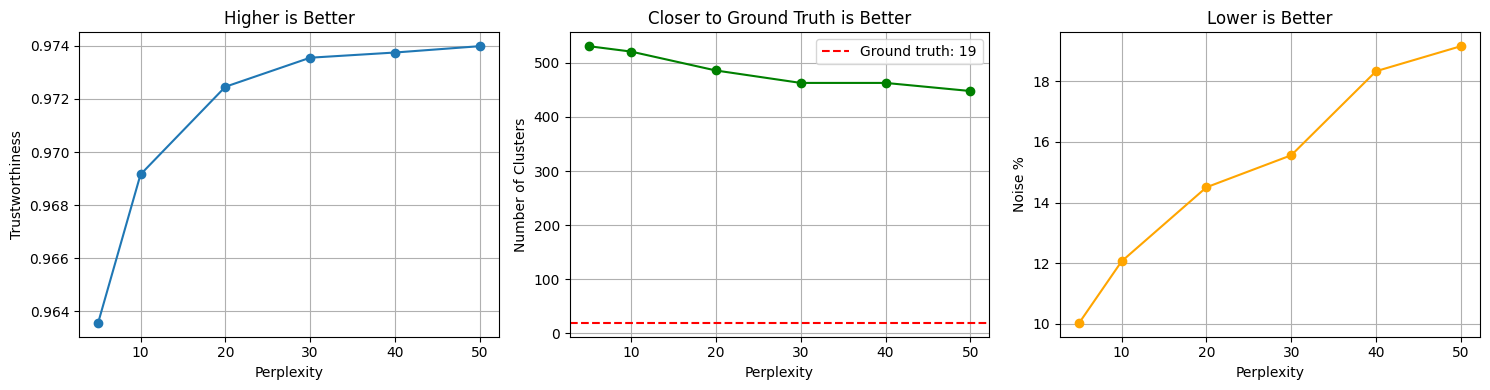

In [6]:
# Test different perplexity values (OPTIONAL - takes time!)
# Comment this out if you want to skip and use recommended parameters
from sklearn.metrics import silhouette_score
from sklearn.manifold import trustworthiness
import hdbscan

# Get number of ground truth classes
n_classes = df['calltype'].nunique()

# Test a range of perplexities
perplexities_to_test = [5, 10, 20, 30, 40, 50]
tsne_results = []

print("Testing different perplexity values...")
print("This will take several minutes...\n")

for perp in perplexities_to_test:
    print(f"Testing perplexity={perp}...")
    
    tsne_test = TSNE(
        n_components=3, 
        random_state=42, 
        perplexity=perp, 
        max_iter=1000,
        verbose=1
    )
    X_tsne_test = tsne_test.fit_transform(X)
    
    # Calculate quality metrics
    # Trustworthiness: how well local structure is preserved (higher is better)
    trust = trustworthiness(X, X_tsne_test, n_neighbors=12)
    
    # Quick HDBSCAN to check cluster quality
    clusterer_test = hdbscan.HDBSCAN(min_cluster_size=5, min_samples=1)
    labels_test = clusterer_test.fit_predict(X_tsne_test)
    n_clusters = len(set(labels_test)) - (1 if -1 in labels_test else 0)
    pct_noise = 100 * sum(labels_test == -1) / len(labels_test)
    
    # Silhouette score if we have clusters
    if n_clusters > 1:
        non_noise = labels_test != -1
        if sum(non_noise) > 0:
            sil = silhouette_score(X_tsne_test[non_noise], labels_test[non_noise])
        else:
            sil = -1
    else:
        sil = -1
    
    tsne_results.append({
        'perplexity': perp,
        'trustworthiness': trust,
        'n_clusters': n_clusters,
        'pct_noise': pct_noise,
        'silhouette': sil
    })
    
    print(f"  Trustworthiness: {trust:.3f}, Clusters: {n_clusters}, Noise: {pct_noise:.1f}%, Silhouette: {sil:.3f}\n")

# Display results
tsne_results_df = pd.DataFrame(tsne_results)
print("\n" + "=" * 70)
print("PERPLEXITY COMPARISON RESULTS")
print("=" * 70)
print(tsne_results_df.to_string(index=False))

print(f"\nBest perplexity by trustworthiness: {tsne_results_df.loc[tsne_results_df['trustworthiness'].idxmax(), 'perplexity']:.0f}")
print(f"Best perplexity by silhouette score: {tsne_results_df.loc[tsne_results_df['silhouette'].idxmax(), 'perplexity']:.0f}")

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(tsne_results_df['perplexity'], tsne_results_df['trustworthiness'], 'o-')
axes[0].set_xlabel('Perplexity')
axes[0].set_ylabel('Trustworthiness')
axes[0].set_title('Higher is Better')
axes[0].grid(True)

axes[1].plot(tsne_results_df['perplexity'], tsne_results_df['n_clusters'], 'o-', color='green')
axes[1].axhline(n_classes, color='red', linestyle='--', label=f'Ground truth: {n_classes}')
axes[1].set_xlabel('Perplexity')
axes[1].set_ylabel('Number of Clusters')
axes[1].set_title('Closer to Ground Truth is Better')
axes[1].legend()
axes[1].grid(True)

axes[2].plot(tsne_results_df['perplexity'], tsne_results_df['pct_noise'], 'o-', color='orange')
axes[2].set_xlabel('Perplexity')
axes[2].set_ylabel('Noise %')
axes[2].set_title('Lower is Better')
axes[2].grid(True)

plt.tight_layout()
plt.show()

### Optional: Test Multiple Perplexity Values

In [24]:
# Analyze dataset to recommend t-SNE parameters
n_samples = len(df)
n_features = len(embedding_cols)
n_classes = df['calltype'].nunique()

print("=" * 60)
print("DATASET CHARACTERISTICS FOR t-SNE PARAMETER SELECTION")
print("=" * 60)
print(f"\nNumber of samples: {n_samples}")
print(f"Number of features: {n_features}")
print(f"Number of call types: {n_classes}")

print(f"\n{'=' * 60}")
print("RECOMMENDED t-SNE PARAMETERS")
print("=" * 60)

# Perplexity recommendations
print(f"\nPerplexity (balance between local and global structure):")
print(f"  - Rule of thumb: 5 to 50, typically sqrt(n_samples)/2")
print(f"  - For your data ({n_samples} samples):")
recommended_perplexity = int(np.sqrt(n_samples) / 2)
print(f"    * Recommended: {recommended_perplexity}")
print(f"    * Conservative range: {max(5, recommended_perplexity-10)} to {min(50, recommended_perplexity+10)}")
print(f"    * Lower perplexity (5-15): Focus on local structure")
print(f"    * Higher perplexity (30-50): Focus on global structure")

print(f"\nLearning rate:")
print(f"  - Default: 200 (usually works well)")
print(f"  - Try range: {max(10, n_samples/12):.0f} to 1000")
print(f"  - If clusters too compressed: increase learning_rate")
print(f"  - If clusters too spread: decrease learning_rate")

print(f"\nIterations (max_iter):")
print(f"  - Minimum: 1000 (recommended for this dataset size)")
print(f"  - For {n_samples} samples: 1000-2000 iterations should suffice")
print(f"  - Watch for convergence message in verbose output")

print(f"\nComponents (n_components):")
print(f"  - Current: 3 (for 3D visualization)")
print(f"  - Alternative: 2 (simpler, faster, easier to visualize)")
print(f"  - Note: 3D better preserves structure but harder to interpret")

DATASET CHARACTERISTICS FOR t-SNE PARAMETER SELECTION

Number of samples: 6047
Number of features: 1026
Number of call types: 19

RECOMMENDED t-SNE PARAMETERS

Perplexity (balance between local and global structure):
  - Rule of thumb: 5 to 50, typically sqrt(n_samples)/2
  - For your data (6047 samples):
    * Recommended: 38
    * Conservative range: 28 to 48
    * Lower perplexity (5-15): Focus on local structure
    * Higher perplexity (30-50): Focus on global structure

Learning rate:
  - Default: 200 (usually works well)
  - Try range: 504 to 1000
  - If clusters too compressed: increase learning_rate
  - If clusters too spread: decrease learning_rate

Iterations (max_iter):
  - Minimum: 1000 (recommended for this dataset size)
  - For 6047 samples: 1000-2000 iterations should suffice
  - Watch for convergence message in verbose output

Components (n_components):
  - Current: 3 (for 3D visualization)
  - Alternative: 2 (simpler, faster, easier to visualize)
  - Note: 3D better pr

Dimensionality reduction via t-SNE

In [6]:
import pandas as pd
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Load the CSV with embeddings and calltype
csv_path = "/home/Shelby/blackbird_calls/Experiments/Detection_of_calls/Datasets/All_call_classes/Split_data_controlled/OpenSoundScape/birds_embeddings_birdnet_padded_3s.csv"
df = pd.read_csv(csv_path)

print(f"Loaded data with shape: {df.shape}")
print(f"Columns: {df.columns.tolist()[:5]}...")  # Show first 5 columns

# Separate metadata from embeddings
# Assuming 'calltype' and 'file' are metadata columns, rest are embeddings
metadata_cols = ['calltype', 'file']
embedding_cols = [col for col in df.columns if col not in metadata_cols]

print(f"\nNumber of embedding features: {len(embedding_cols)}")

# Extract embeddings as numpy array
X = df[embedding_cols].values
y = df['calltype'].values

# Run t-SNE
print("\nRunning t-SNE...")
tsne = TSNE(n_components=3, random_state=42, perplexity=38, max_iter=1000, verbose=1)
X_tsne = tsne.fit_transform(X)

print("t-SNE transformation complete!")

# Create a DataFrame with t-SNE results
tsne_df = pd.DataFrame({
    'TSNE1': X_tsne[:, 0],
    'TSNE2': X_tsne[:, 1],
    'TSNE3': X_tsne[:, 2],
    'calltype': y
})

Loaded data with shape: (6047, 1028)
Columns: ['calltype', 'file', 'start_time', 'end_time', '0']...

Number of embedding features: 1026

Running t-SNE...
[t-SNE] Computing 115 nearest neighbors...
[t-SNE] Indexed 6047 samples in 0.022s...
[t-SNE] Computed neighbors for 6047 samples in 0.428s...
[t-SNE] Computed conditional probabilities for sample 1000 / 6047
[t-SNE] Computed conditional probabilities for sample 2000 / 6047
[t-SNE] Computed conditional probabilities for sample 3000 / 6047
[t-SNE] Computed conditional probabilities for sample 4000 / 6047
[t-SNE] Computed conditional probabilities for sample 5000 / 6047
[t-SNE] Computed conditional probabilities for sample 6000 / 6047
[t-SNE] Computed conditional probabilities for sample 6047 / 6047
[t-SNE] Mean sigma: 0.000000
[t-SNE] KL divergence after 250 iterations with early exaggeration: 79.347336
[t-SNE] KL divergence after 1000 iterations: 1.329067
t-SNE transformation complete!


Visualize clusters (2D t-SNE)

In [8]:
# Grid search to find optimal parameters
# This will test different parameter combinations and evaluate against ground truth
import hdbscan
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score

# Define parameter ranges based on your data
min_cluster_sizes = [3, 5, 10, 15, 20]
min_samples_list = [1, 3, 5]

results = []

print("Running parameter grid search...")
print("This may take a few minutes...\n")

for mcs in min_cluster_sizes:
    for ms in min_samples_list:
        if ms > mcs:
            continue  # Skip invalid combinations
        
        # Run clustering
        clusterer_test = hdbscan.HDBSCAN(
            min_cluster_size=mcs,
            min_samples=ms,
            metric='euclidean',
            cluster_selection_method='eom'
        )
        labels = clusterer_test.fit_predict(X_tsne)
        
        # Calculate metrics
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = sum(labels == -1)
        pct_noise = 100 * n_noise / len(labels)
        
        # Quality metrics (excluding noise)
        non_noise_mask = labels != -1
        if sum(non_noise_mask) > 0:
            ari = adjusted_rand_score(y[non_noise_mask], labels[non_noise_mask])
            nmi = normalized_mutual_info_score(y[non_noise_mask], labels[non_noise_mask])
            
            # Silhouette score (if we have clusters)
            if n_clusters > 1:
                sil = silhouette_score(X_tsne[non_noise_mask], labels[non_noise_mask])
            else:
                sil = -1
        else:
            ari = nmi = sil = -1
        
        results.append({
            'min_cluster_size': mcs,
            'min_samples': ms,
            'n_clusters': n_clusters,
            'pct_noise': pct_noise,
            'ARI': ari,
            'NMI': nmi,
            'Silhouette': sil
        })
        
        print(f"mcs={mcs:2d}, ms={ms}, clusters={n_clusters:2d}, noise={pct_noise:5.1f}%, ARI={ari:.3f}, NMI={nmi:.3f}")

# Convert to DataFrame and display
results_df = pd.DataFrame(results)
print("\n" + "=" * 70)
print("PARAMETER SEARCH RESULTS")
print("=" * 70)
print("\nTop 5 by Adjusted Rand Index (ARI):")
print(results_df.nlargest(5, 'ARI')[['min_cluster_size', 'min_samples', 'n_clusters', 'pct_noise', 'ARI', 'NMI']])

print("\nTop 5 by Normalized Mutual Information (NMI):")
print(results_df.nlargest(5, 'NMI')[['min_cluster_size', 'min_samples', 'n_clusters', 'pct_noise', 'ARI', 'NMI']])

# Find balanced parameters (good metrics + reasonable noise)
results_df['score'] = results_df['ARI'] + results_df['NMI'] - (results_df['pct_noise'] / 100)
print("\nTop 5 by Balanced Score (ARI + NMI - noise%):")
print(results_df.nlargest(5, 'score')[['min_cluster_size', 'min_samples', 'n_clusters', 'pct_noise', 'ARI', 'NMI']])

Running parameter grid search...
This may take a few minutes...

mcs= 3, ms=1, clusters=949, noise= 15.3%, ARI=0.003, NMI=0.338
mcs= 3, ms=3, clusters=488, noise= 27.4%, ARI=0.011, NMI=0.383
mcs= 5, ms=1, clusters=466, noise= 17.4%, ARI=0.009, NMI=0.362
mcs= 5, ms=3, clusters=341, noise= 26.0%, ARI=0.014, NMI=0.388
mcs= 5, ms=5, clusters=220, noise= 37.1%, ARI=0.025, NMI=0.422
mcs=10, ms=1, clusters=211, noise= 19.5%, ARI=0.017, NMI=0.376
mcs=10, ms=3, clusters=177, noise= 28.0%, ARI=0.022, NMI=0.399
mcs=10, ms=5, clusters=136, noise= 38.3%, ARI=0.035, NMI=0.434
mcs=15, ms=1, clusters=133, noise= 24.1%, ARI=0.024, NMI=0.388
mcs=15, ms=3, clusters=113, noise= 29.0%, ARI=0.030, NMI=0.400
mcs=15, ms=5, clusters=101, noise= 40.6%, ARI=0.043, NMI=0.440
mcs=20, ms=1, clusters=102, noise= 25.6%, ARI=0.028, NMI=0.389
mcs=20, ms=3, clusters=89, noise= 30.9%, ARI=0.034, NMI=0.405
mcs=20, ms=5, clusters=28, noise= 10.0%, ARI=0.453, NMI=0.500

PARAMETER SEARCH RESULTS

Top 5 by Adjusted Rand Index

### Parameter Grid Search (Optional)

In [ ]:
# Analyze ground truth call type distribution
calltype_counts = df['calltype'].value_counts().sort_values()

print("=" * 60)
print("GROUND TRUTH CALL TYPE DISTRIBUTION")
print("=" * 60)
print(f"\nTotal samples: {len(df)}")
print(f"Number of call types: {len(calltype_counts)}")
print(f"\nSamples per call type:")
print(calltype_counts)

print(f"\n--- Statistics ---")
print(f"Minimum samples per type: {calltype_counts.min()}")
print(f"Maximum samples per type: {calltype_counts.max()}")
print(f"Mean samples per type: {calltype_counts.mean():.1f}")
print(f"Median samples per type: {calltype_counts.median():.1f}")

# Parameter recommendations
print(f"\n{'=' * 60}")
print("RECOMMENDED PARAMETER RANGES")
print("=" * 60)
print(f"\nmin_cluster_size:")
print(f"  - Conservative (avoid small clusters): {int(calltype_counts.median() * 0.5)} - {int(calltype_counts.median())}")
print(f"  - Moderate (balance): {int(calltype_counts.min() * 0.5)} - {int(calltype_counts.median() * 0.5)}")
print(f"  - Aggressive (find small clusters): {max(2, int(calltype_counts.min() * 0.3))} - {int(calltype_counts.min() * 0.7)}")

print(f"\nmin_samples:")
print(f"  - Start with: 1 (most inclusive) to {max(3, int(calltype_counts.min() * 0.2))} (more conservative)")
print(f"  - Rule of thumb: min_samples <= min_cluster_size")

# Visualize distribution
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
calltype_counts.plot(kind='barh')
plt.xlabel('Number of Samples')
plt.ylabel('Call Type')
plt.title('Ground Truth: Samples per Call Type')
plt.axvline(calltype_counts.median(), color='r', linestyle='--', label=f'Median: {calltype_counts.median():.0f}')
plt.axvline(calltype_counts.mean(), color='g', linestyle='--', label=f'Mean: {calltype_counts.mean():.0f}')
plt.legend()
plt.tight_layout()
plt.show()

## Analyze Ground Truth to Guide Parameter Selection

In [9]:
import hdbscan

# Run HDBSCAN on the t-SNE-reduced embeddings
# To reduce noise points, try:
# - Decrease min_cluster_size (allows smaller clusters)
# - Decrease min_samples (makes it easier for points to join clusters)
# - Change cluster_selection_method to 'leaf' (less conservative)
print("Running HDBSCAN clustering...")
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=21,      # Reduced from 5 to allow smaller clusters
    min_samples=5,            # Reduced from 3 to include more points in clusters
    metric='euclidean',
    cluster_selection_epsilon=0.0,
    cluster_selection_method='eom'  # Try 'leaf' if still too much noise
)

# Fit the clusterer
cluster_labels = clusterer.fit_predict(X_tsne)

# Add cluster labels to the dataframe
df['cluster'] = cluster_labels

print(f"Clustering complete!")
print(f"Number of clusters found: {len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)}")
print(f"Number of noise points: {sum(cluster_labels == -1)}")
print(f"Percentage of noise: {100 * sum(cluster_labels == -1) / len(cluster_labels):.1f}%")
print(f"Cluster distribution:\n{pd.Series(cluster_labels).value_counts().sort_index()}")

Running HDBSCAN clustering...
Clustering complete!
Number of clusters found: 26
Number of noise points: 590
Percentage of noise: 9.8%
Cluster distribution:
-1      590
 0       63
 1       53
 2       21
 3      134
 4       24
 5       54
 6       74
 7       21
 8       62
 9       35
 10      44
 11      23
 12      21
 13      38
 14      70
 15      40
 16      65
 17      31
 18      37
 19      58
 20      41
 21    4346
 22      24
 23      22
 24      31
 25      25
Name: count, dtype: int64


/tmp/ipykernel_545105/2449609784.py:21: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



/tmp/ipykernel_545105/40610396.py:7: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



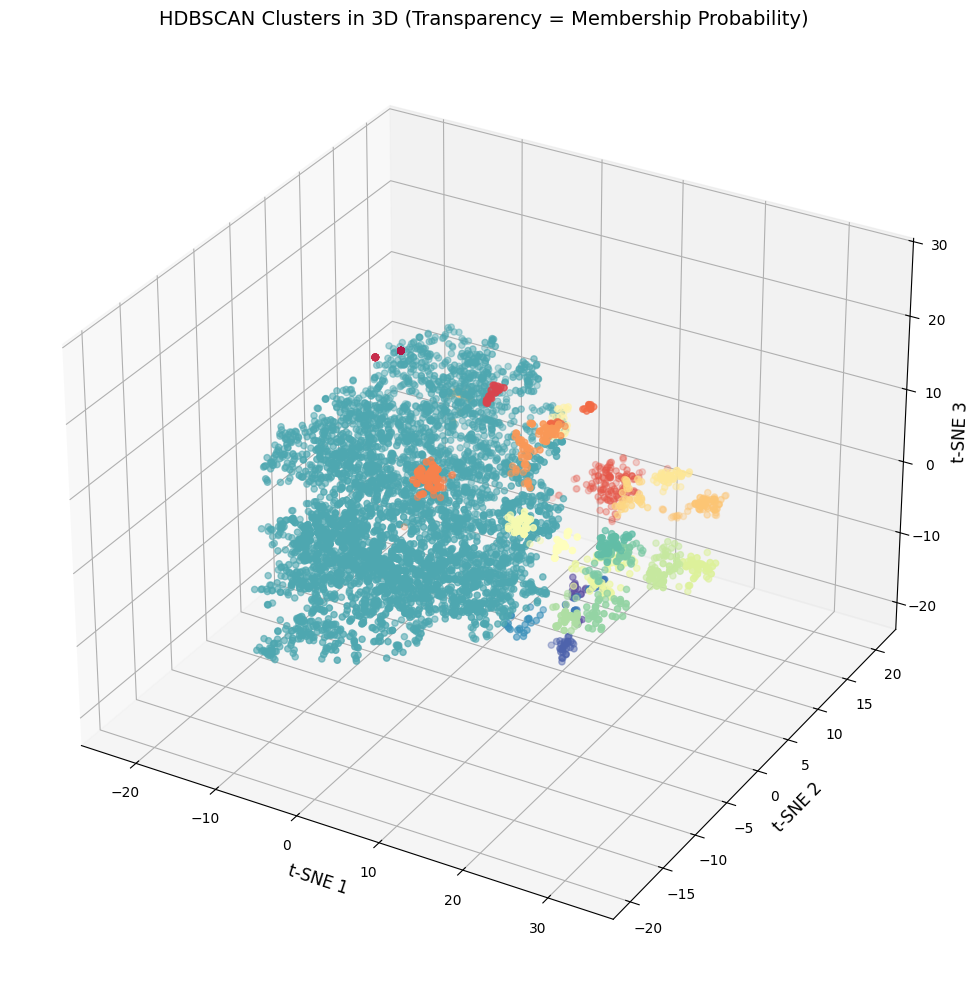

In [13]:
# 3D plot with transparency based on membership probability
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Create rgba colors with alpha based on probabilities
import matplotlib.cm as cm
cmap = cm.get_cmap('Spectral')
norm = plt.Normalize(vmin=cluster_labels.min(), vmax=cluster_labels.max())
colors_rgba = [cmap(norm(label)) for label in cluster_labels]

# Set alpha based on probabilities
for i, (color, prob) in enumerate(zip(colors_rgba, clusterer.probabilities_)):
    colors_rgba[i] = (*color[:3], prob)

ax.scatter(
    X_tsne[:, 0], 
    X_tsne[:, 1], 
    X_tsne[:, 2],
    c=colors_rgba,
    s=20
)

ax.set_xlabel('t-SNE 1', fontsize=12)
ax.set_ylabel('t-SNE 2', fontsize=12)
ax.set_zlabel('t-SNE 3', fontsize=12)
ax.set_title('HDBSCAN Clusters in 3D (Transparency = Membership Probability)', fontsize=14)

plt.tight_layout()
plt.show()

In [14]:
# Alternative: Color by ground truth call types (interactive)
import plotly.express as px

# Create dataframe for plotting
plot_df = pd.DataFrame({
    'TSNE1': X_tsne[:, 0],
    'TSNE2': X_tsne[:, 1],
    'TSNE3': X_tsne[:, 2],
    'Cluster': cluster_labels,
    'Call Type': y,
    'Probability': clusterer.probabilities_,
    'Outlier Score': clusterer.outlier_scores_
})

fig2 = px.scatter_3d(
    plot_df,
    x='TSNE1',
    y='TSNE2',
    z='TSNE3',
    color='Call Type',
    hover_data=['Cluster', 'Probability'],
    title='Interactive 3D: Colored by Ground Truth Call Type',
    opacity=0.7,
    width=1000,
    height=800
)

fig2.update_traces(marker=dict(size=3))
fig2.update_layout(
    scene=dict(
        xaxis_title='t-SNE 1',
        yaxis_title='t-SNE 2',
        zaxis_title='t-SNE 3'
    )
)

fig2.show()

/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/site-packages/hdbscan/hdbscan_.py:1509: RuntimeWarning:

invalid value encountered in scalar divide



In [ ]:
import plotly.graph_objects as go
import plotly.express as px

# Create interactive 3D scatter plot with Plotly (uses plot_df from previous cell)
# Group by CALL TYPE instead of cluster for better filtering
fig = go.Figure()

# Get unique call types and create color palette
unique_calltypes = sorted(plot_df['Call Type'].unique())
colors = px.colors.qualitative.Plotly + px.colors.qualitative.Set2 + px.colors.qualitative.Set3

# Plot each call type as a separate trace
for i, calltype in enumerate(unique_calltypes):
    calltype_data = plot_df[plot_df['Call Type'] == calltype]
    
    fig.add_trace(go.Scatter3d(
        x=calltype_data['TSNE1'],
        y=calltype_data['TSNE2'],
        z=calltype_data['TSNE3'],
        mode='markers',
        name=calltype,
        marker=dict(
            size=3,
            color=colors[i % len(colors)],
            opacity=0.7,
            line=dict(width=0)
        ),
        text=[f"Call Type: {ct}<br>Cluster: {c}<br>Probability: {p:.3f}" 
              for ct, c, p in zip(calltype_data['Call Type'], 
                                  calltype_data['Cluster'], 
                                  calltype_data['Probability'])],
        hovertemplate='<b>%{text}</b><br>TSNE1: %{x:.2f}<br>TSNE2: %{y:.2f}<br>TSNE3: %{z:.2f}<extra></extra>'
    ))

fig.update_layout(
    title='Interactive 3D by Call Type (Click and Drag to Rotate)',
    scene=dict(
        xaxis_title='t-SNE 1',
        yaxis_title='t-SNE 2',
        zaxis_title='t-SNE 3',
        camera=dict(
            eye=dict(x=1.5, y=1.5, z=1.5)
        )
    ),
    width=1000,
    height=800,
    showlegend=True
)

### Add dropdown to highlight specific call types ###
# Build button list for dropdown
buttons = []

# "All Call Types" button - show all with original colors
all_colors = [colors[i % len(colors)] for i in range(len(unique_calltypes))]
all_opacities = [0.7] * len(unique_calltypes)

buttons.append({
    'label': 'All Call Types',
    'method': 'restyle',
    'args': [{'marker.color': all_colors, 'marker.opacity': all_opacities}]
})

# Individual call type buttons
for i, calltype in enumerate(unique_calltypes):
    button_colors = []
    button_opacities = []
    
    for j, ct in enumerate(unique_calltypes):
        if ct == calltype:
            # Highlight the selected call type
            button_colors.append(colors[j % len(colors)])
            button_opacities.append(0.9)
        else:
            # Gray out other call types
            button_colors.append('lightgray')
            button_opacities.append(0.15)
    
    buttons.append({
        'label': calltype,
        'method': 'restyle',
        'args': [{'marker.color': button_colors, 'marker.opacity': button_opacities}]
    })

fig.update_layout(
    updatemenus=[{
        'buttons': buttons,
        'direction': 'down',
        'showactive': True,
        'x': 0.17,
        'xanchor': 'left',
        'y': 1.15,
        'yanchor': 'top'
    }]
)

fig.show()

### Interactive 3D Visualization (Rotatable)

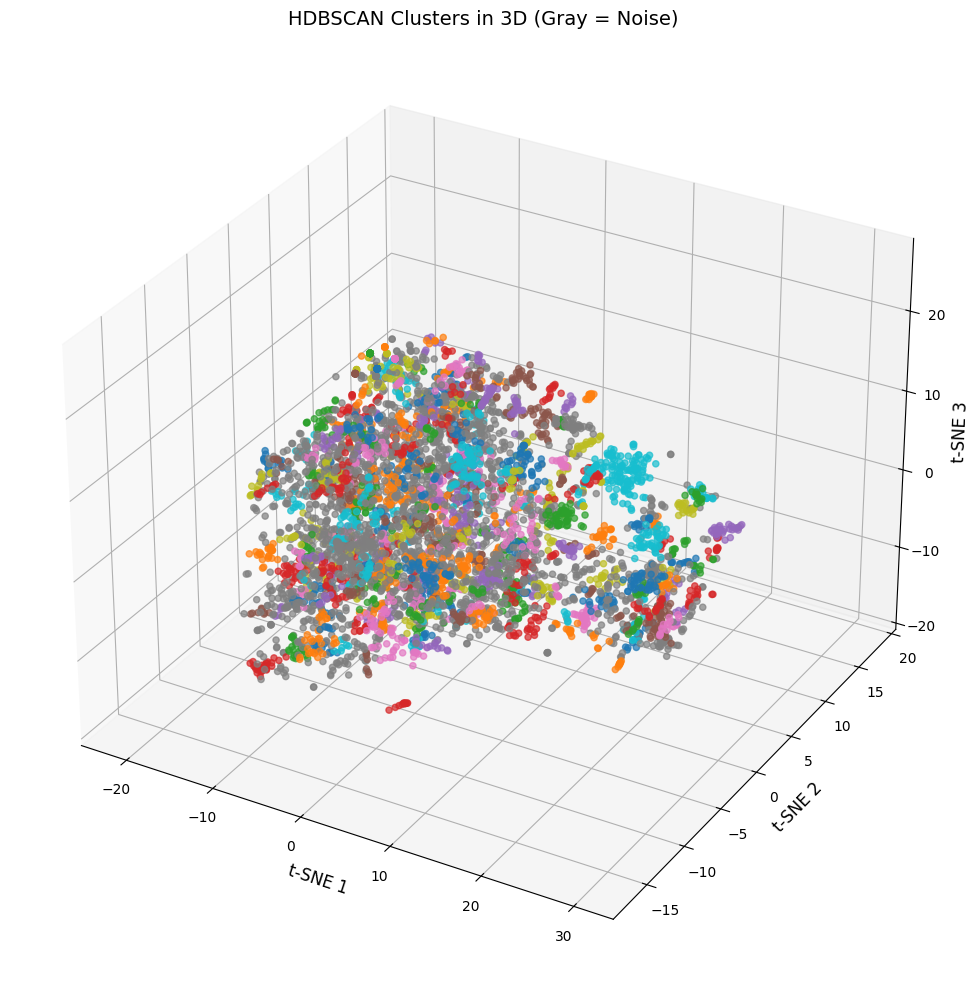

In [13]:
# 3D plot with noise points in gray
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

colors = ['gray' if label == -1 else f'C{label % 10}' for label in cluster_labels]
ax.scatter(
    X_tsne[:, 0], 
    X_tsne[:, 1], 
    X_tsne[:, 2],
    c=colors,
    s=20,
    alpha=0.7
)

ax.set_xlabel('t-SNE 1', fontsize=12)
ax.set_ylabel('t-SNE 2', fontsize=12)
ax.set_zlabel('t-SNE 3', fontsize=12)
ax.set_title('HDBSCAN Clusters in 3D (Gray = Noise)', fontsize=14)

plt.tight_layout()
plt.show()

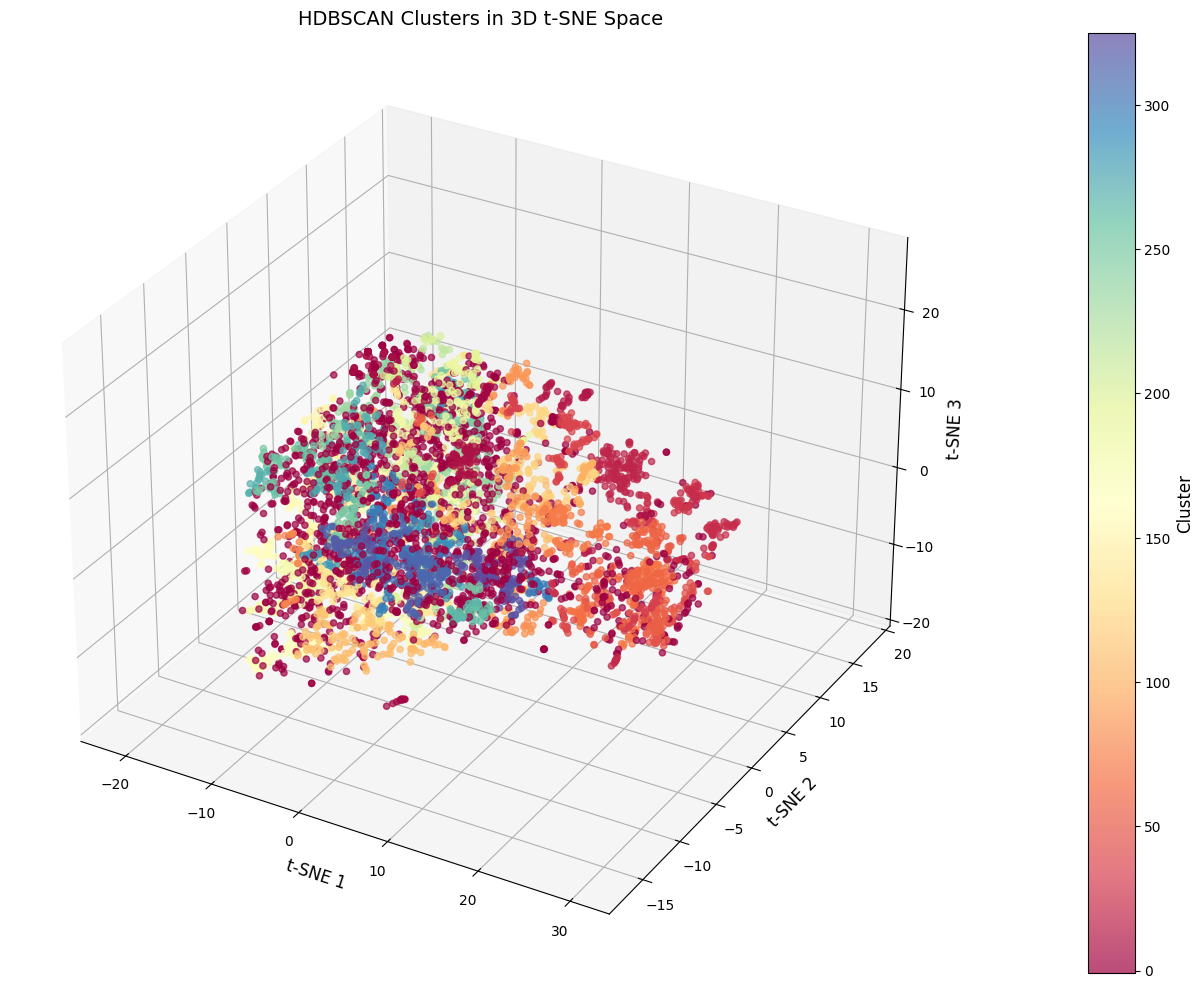

In [14]:
from mpl_toolkits.mplot3d import Axes3D

# Create 3D scatter plot
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot with cluster colors
scatter = ax.scatter(
    X_tsne[:, 0], 
    X_tsne[:, 1], 
    X_tsne[:, 2],
    c=cluster_labels,
    cmap='Spectral',
    s=20,
    alpha=0.7
)

ax.set_xlabel('t-SNE 1', fontsize=12)
ax.set_ylabel('t-SNE 2', fontsize=12)
ax.set_zlabel('t-SNE 3', fontsize=12)
ax.set_title('HDBSCAN Clusters in 3D t-SNE Space', fontsize=14)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax, pad=0.1)
cbar.set_label('Cluster', fontsize=12)

plt.tight_layout()
plt.show()

Compare clusters with ground truth call types

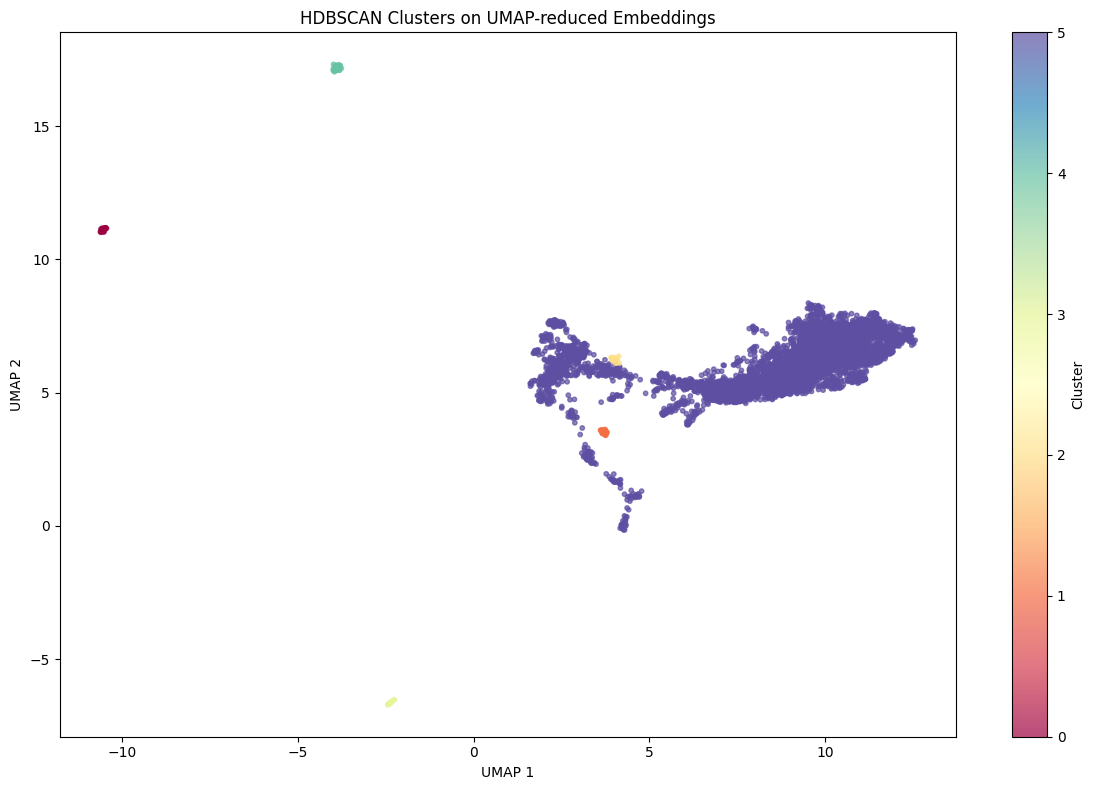

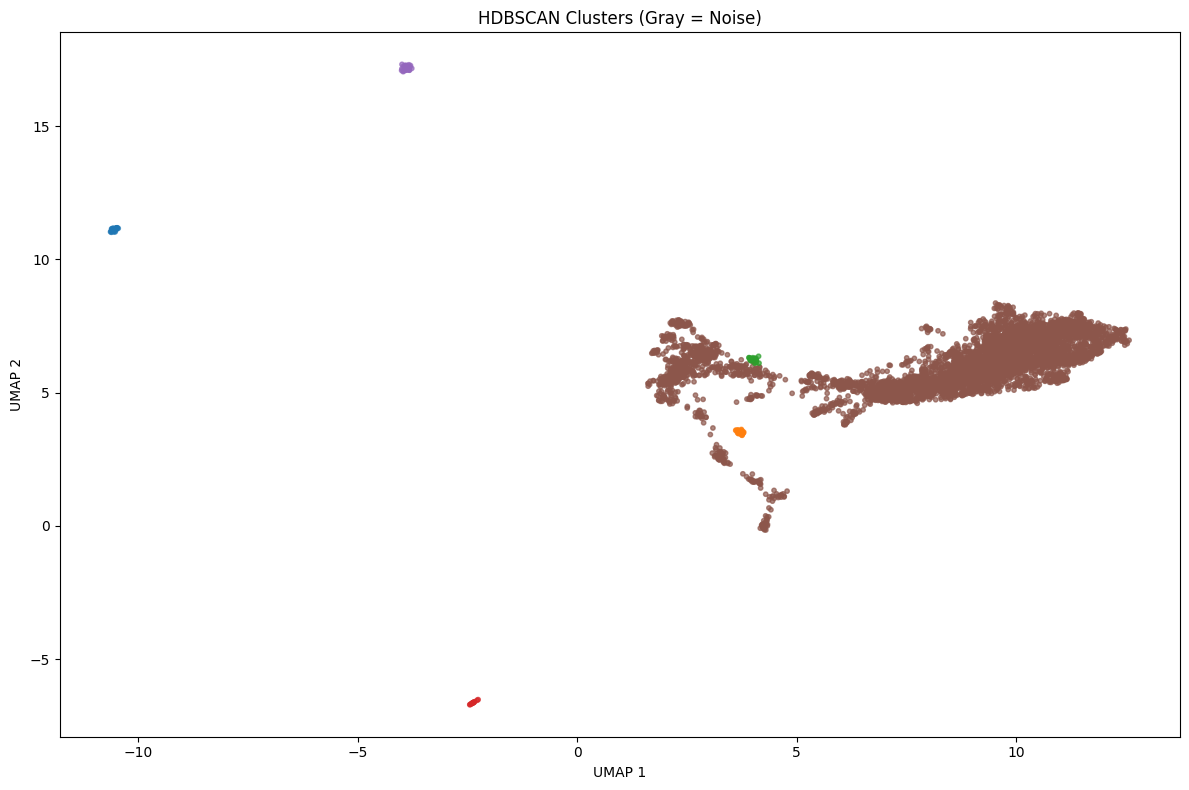

In [ ]:
# Visualize clusters in 2D t-SNE space
plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    X_tsne[:, 0], 
    X_tsne[:, 1], 
    c=cluster_labels, 
    cmap='Spectral',
    s=10,
    alpha=0.7
)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('HDBSCAN Clusters on t-SNE-reduced Embeddings')
plt.tight_layout()
plt.show()

# Noise points in gray
plt.figure(figsize=(12, 8))
colors = ['gray' if label == -1 else f'C{label % 10}' for label in cluster_labels]
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=colors, s=10, alpha=0.7)
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('HDBSCAN Clusters (Gray = Noise)')
plt.tight_layout()
plt.show()

### Cluster Probabilities and Outlier Scores

In [67]:
# Cross-tabulation of clusters vs call types
print("Cross-tabulation of Clusters vs Call Types:")
crosstab = pd.crosstab(df['cluster'], df['calltype'], margins=True)
print(crosstab)

# Calculate purity metrics
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, homogeneity_completeness_v_measure

# Filter out noise points for some metrics
non_noise_mask = cluster_labels != -1
if sum(non_noise_mask) > 0:
    ari = adjusted_rand_score(y[non_noise_mask], cluster_labels[non_noise_mask])
    nmi = normalized_mutual_info_score(y[non_noise_mask], cluster_labels[non_noise_mask])
    homogeneity, completeness, v_measure = homogeneity_completeness_v_measure(y[non_noise_mask], cluster_labels[non_noise_mask])
    
    print(f"\n--- Clustering Quality Metrics (excluding noise) ---")
    print(f"Adjusted Rand Index: {ari:.3f}")
    print(f"Normalized Mutual Information: {nmi:.3f}")
    print(f"Homogeneity: {homogeneity:.3f}")
    print(f"Completeness: {completeness:.3f}")
    print(f"V-measure: {v_measure:.3f}")

Cross-tabulation of Clusters vs Call Types:
calltype   A    B    C  Check  Cheer  Chits    D    E    F   G  Growl   H   I  \
cluster                                                                         
0          0    0    0     26      5      4    0    1    2   1      0   0   5   
1          0    0    0     19      5      2    0    0    1   3      0   0   2   
2          0    0    0     15      7      1    0    1    0   2      0   0   1   
3          0    0    0      0      0      0    0    0    0   0      0   0  14   
4          0    1    0     18      3      2    0    0    0   2      0   0   3   
5          0   21    0      0      0      0    0    0    0   0      0   0   0   
6         20  114  202   3571    687    153  201  246  253  69      5  14  50   
All       20  136  202   3649    707    162  201  248  256  77      5  14  75   

calltype   J    K   L   M   N   O   All  
cluster                                  
0          1    0   0   0   0   0    45  
1          0    1  

Plot

/tmp/ipykernel_500949/1482933329.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['cluster_probability'] = clusterer.probabilities_
/tmp/ipykernel_500949/1482933329.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['outlier_score'] = clusterer.outlier_scores_


Cluster membership probabilities:
  calltype  cluster  cluster_probability  outlier_score
0        D      212             0.957501       0.042499
1        F      230             1.000000       0.000000
2        F      254             0.778215       0.221785
3    Cheer       -1             0.000000       0.022007
4    Check      174             0.658270       0.341730
5    Cheer       42             1.000000       0.000000
6    Check      150             1.000000       0.000000
7        I       -1             0.000000       0.026627
8    Cheer       23             1.000000       0.000000
9    Cheer      227             1.000000       0.000000


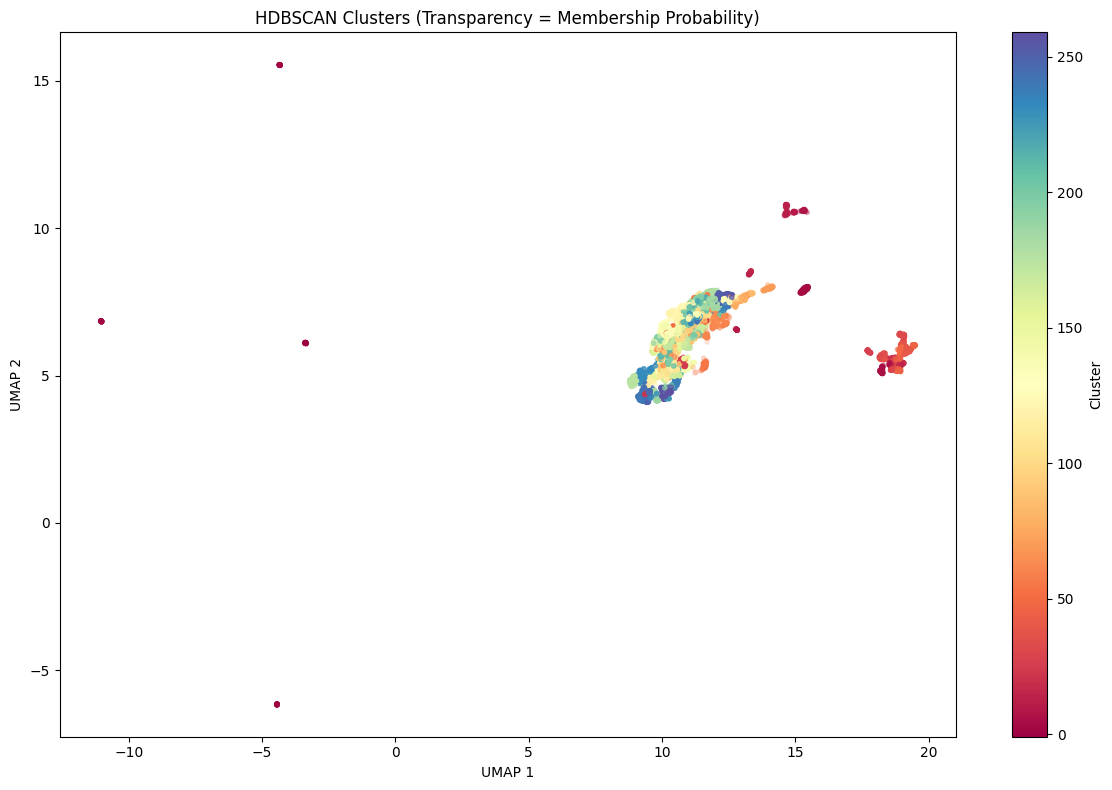

In [ ]:
# HDBSCAN provides membership probabilities and outlier scores
df['cluster_probability'] = clusterer.probabilities_
df['outlier_score'] = clusterer.outlier_scores_

print("Cluster membership probabilities:")
print(df[['calltype', 'cluster', 'cluster_probability', 'outlier_score']].head(10))

# Visualize with probability-based transparency
plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    X_tsne[:, 0], 
    X_tsne[:, 1], 
    c=cluster_labels,
    cmap='Spectral',
    s=10,
    alpha=clusterer.probabilities_  # Alpha based on membership probability
)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('HDBSCAN Clusters (Transparency = Membership Probability)')
plt.tight_layout()
plt.show()

## HDBSCAN Clustering